In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# An activity coefficient measured with a separatory funnel (Illustration 11.4-1)

This notebook works **Illustration 11.4-1**: bromine shaken with carbon tetrachloride
and water, and the resulting ratio of activity coefficients. Then it works
**Problem 11.4-3**, which turns that ratio into the activity coefficient of bromine in
water itself -- a number of order 300, obtained without measuring anything but
concentrations.

**The whole thermodynamic content is Eq. 11.4-5.** Both phases are liquids, so the pure
bromine fugacity cancels from the equilibrium condition and

$$K_x = \frac{x_1^{\rm I}}{x_1^{\rm II}}
      = \frac{\gamma_1^{\rm II}}{\gamma_1^{\rm I}}$$

There is no model, no solver, and nothing iterative. A measured partitioning *is* a
ratio of activity coefficients.

**The work is all in the units, and that is the reason for a notebook.** The data are
concentration distribution coefficients, in kmol of bromine per cubic meter of solution,
and Eq. 11.4-5 is written in mole fractions. Converting needs the molar volumes of both
solvents and of the solute, and the correction changes sign between the two phases:
positive in carbon tetrachloride, negative in water. A conversion written once with an
assumed sign is wrong for one of the two phases in this illustration.

Data: *International Critical Tables*, Vol. 3 (McGraw-Hill, New York, 1929) -- SIS
footnote 17. That is a compilation rather than a primary source, and the original
measurement behind it has not been traced.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.charts import use_book_style
from thermo.partition import Kx_from_Kc
from thermo.activity_models import RegularSolution

use_book_style()

# Pure-species data as the illustration prints them: molecular weight, density kg/m^3.
BR2 = (159.83, 3119.0)
CCL4 = (153.84, 1595.0)
H2O = (18.0, 1000.0)

# The measured concentration distribution coefficient at 25 C. C is kmol Br2 per m^3
# of the CCl4 solution; Kc is that divided by the concentration in the aqueous phase.
C_ORGANIC = np.array([0.04, 0.10, 0.5, 1.0, 1.5, 2.0, 2.5])
KC = np.array([26.8, 27.2, 29.0, 30.4, 31.4, 33.4, 35.0])

# The printed answers, for comparison.
SIS_X_CCL4 = np.array([3.85e-3, 9.60e-3, 4.70e-2, 9.23e-2, 0.135, 0.177, 0.217])
SIS_X_H2O = np.array([2.7e-5, 6.6e-5, 3.1e-4, 5.93e-4, 8.62e-4, 1.08e-3, 1.29e-3])
SIS_RATIO = np.array([142.6, 145.4, 151.6, 155.6, 156.6, 163.9, 168.2])

print("  The two conversion coefficients, from the pure-species data alone")
print(f"    CCl4 phase:  m_S/rho_S       = {CCL4[0]/CCL4[1]:.6f}   SIS 0.096 45")
print(f"                 m_S/rho_S - m_B/rho_B = {CCL4[0]/CCL4[1] - BR2[0]/BR2[1]:+.6f}"
      f"   SIS +0.045 21")
print(f"    H2O phase:   m_S/rho_S       = {H2O[0]/H2O[1]:.6f}   SIS 0.018")
print(f"                 m_S/rho_S - m_B/rho_B = {H2O[0]/H2O[1] - BR2[0]/BR2[1]:+.6f}"
      f"   SIS -0.033 24")
print("\n  The sign flips because bromine's molar volume, "
      f"{BR2[0]/BR2[1]*1e3:.1f} L/kmol, sits")
print(f"  below carbon tetrachloride's {CCL4[0]/CCL4[1]*1e3:.1f} and above water's"
      f" {H2O[0]/H2O[1]*1e3:.1f}.")

  The two conversion coefficients, from the pure-species data alone
    CCl4 phase:  m_S/rho_S       = 0.096451   SIS 0.096 45
                 m_S/rho_S - m_B/rho_B = +0.045207   SIS +0.045 21
    H2O phase:   m_S/rho_S       = 0.018000   SIS 0.018
                 m_S/rho_S - m_B/rho_B = -0.033244   SIS -0.033 24

  The sign flips because bromine's molar volume, 51.2 L/kmol, sits
  below carbon tetrachloride's 96.5 and above water's 18.0.


In [3]:

x_ccl4, x_h2o, Kx = Kx_from_Kc(C_ORGANIC, KC, CCL4, H2O, BR2)

print("  Illustration 11.4-1, recomputed")
print(f"  {'C_B':>5s} {'x(CCl4)':>10s} {'SIS':>9s} {'x(H2O)':>11s} {'SIS':>9s}"
      f" {'gamma ratio':>12s} {'SIS':>7s}")
for row in zip(C_ORGANIC, x_ccl4, SIS_X_CCL4, x_h2o, SIS_X_H2O, Kx, SIS_RATIO):
    C, xc, sc, xw, sw, K, sK = row
    print(f"  {C:5.2f} {xc:10.4g} {sc:9.3g} {xw:11.4g} {sw:9.3g} {K:12.2f} {sK:7.1f}")

print(f"\n  Mole fractions: every one of the fourteen matches the printed value to the")
print(f"  digits printed. Largest relative difference"
      f" {100*max(np.max(np.abs(x_ccl4/SIS_X_CCL4 - 1)), np.max(np.abs(x_h2o/SIS_X_H2O - 1))):.1f} %,")
print(f"  which is the rounding of the printed column, not a disagreement.")

  Illustration 11.4-1, recomputed
    C_B    x(CCl4)       SIS      x(H2O)       SIS  gamma ratio     SIS
   0.04   0.003851   0.00385   2.687e-05   2.7e-05       143.34   142.6
   0.10   0.009602    0.0096   6.618e-05   6.6e-05       145.08   145.4
   0.50    0.04716     0.047   0.0003105   0.00031       151.87   151.6
   1.00    0.09228    0.0923   0.0005928  0.000593       155.68   155.6
   1.50     0.1355     0.135   0.0008612  0.000862       157.32   156.6
   2.00     0.1769     0.177     0.00108   0.00108       163.80   163.9
   2.50     0.2166     0.217    0.001289   0.00129       168.10   168.2

  Mole fractions: every one of the fourteen matches the printed value to the
  digits printed. Largest relative difference 0.5 %,
  which is the rounding of the printed column, not a disagreement.


## The ratio column is computed from the rounded mole fractions

Our activity-coefficient ratios differ from the printed ones by up to 0.7, in both
directions, and the cause is visible rather than mysterious: dividing the *printed,
rounded* mole fractions reproduces the printed ratios to 0.05. The middle columns of
that table carry two or three significant figures, and the last column was formed from
them.

In [4]:

from_rounded = SIS_X_CCL4 / SIS_X_H2O
print(f"  {'C_B':>5s} {'from rounded x':>15s} {'SIS printed':>12s}"
      f" {'from unrounded':>15s}")
for C, fr, sK, K in zip(C_ORGANIC, from_rounded, SIS_RATIO, Kx):
    print(f"  {C:5.2f} {fr:15.1f} {sK:12.1f} {K:15.2f}")
print(f"\n  worst difference between the printed column and the rounded quotient:"
      f" {np.max(np.abs(from_rounded - SIS_RATIO)):.2f}")
print(f"  worst difference between the printed column and ours:"
      f" {np.max(np.abs(Kx - SIS_RATIO)):.2f}")
print("\n  So the printed last column is the printed middle columns divided, and the")
print("  values here are the same calculation carried at full precision.")

    C_B  from rounded x  SIS printed  from unrounded
   0.04           142.6        142.6          143.34
   0.10           145.5        145.4          145.08
   0.50           151.6        151.6          151.87
   1.00           155.6        155.6          155.68
   1.50           156.6        156.6          157.32
   2.00           163.9        163.9          163.80
   2.50           168.2        168.2          168.10

  worst difference between the printed column and the rounded quotient: 0.05
  worst difference between the printed column and ours: 0.74

  So the printed last column is the printed middle columns divided, and the
  values here are the same calculation carried at full precision.



## Problem 11.4-3: from a ratio to a number

The illustration's Comment ends with an estimate rather than a calculation: the
regular solution model should describe bromine in carbon tetrachloride, so
$\gamma_{\rm Br_2}^{\rm CCl_4}$ should be "on the order of magnitude of unity," and
therefore $\gamma_{\rm Br_2}^{\rm H_2O}$ should be "a large number, on the order of 100
or more."

Problem 11.4-3 asks for the calculation. Regular solution theory needs no mixture data
at all -- both parameters are pure-component properties, and Table 9.6-1 carries bromine
and carbon tetrachloride:

| | $\underline{V}$ (cc/mol) | $\delta$ (cal/cc)$^{1/2}$ |
|---|---|---|
| bromine | 51.0 | 11.5 |
| carbon tetrachloride | 97.0 | 8.6 |

so $\gamma_{\rm Br_2}^{\rm CCl_4}$ follows from Eq. 9.6-10 at each of the seven
compositions, and the measured ratio then gives the aqueous activity coefficient.

In [5]:

rs = RegularSolution.from_table_9_6_1([51.0, 97.0], [11.5, 8.6])       # Table 9.6-1
T = 298.15

gamma_org = np.array([rs.gamma([x, 1 - x], T)[0] for x in x_ccl4])
gamma_aq = gamma_org * Kx

print("  Problem 11.4-3")
print(f"  {'C_B':>5s} {'x(CCl4)':>9s} {'gamma_Br2(CCl4)':>16s} {'ratio':>8s}"
      f" {'gamma_Br2(H2O)':>15s}")
for C, xc, go, K, ga in zip(C_ORGANIC, x_ccl4, gamma_org, Kx, gamma_aq):
    print(f"  {C:5.2f} {xc:9.4f} {go:16.3f} {K:8.1f} {ga:15.0f}")

print(f"\n  gamma in CCl4 runs {gamma_org.min():.2f} to {gamma_org.max():.2f}"
      f"  -- 'of the order of magnitude of unity', as the Comment says")
print(f"  gamma in water   runs {gamma_aq.min():.0f} to {gamma_aq.max():.0f}"
      f"    -- 'on the order of 100 or more', as the Comment says")
print(f"\n  and the aqueous value is nearly constant: mean {gamma_aq.mean():.0f},"
      f" spread {100*gamma_aq.std()/gamma_aq.mean():.1f} %")
print(f"  over a {C_ORGANIC[-1]/C_ORGANIC[0]:.0f}-fold range of bromine concentration.")

  Problem 11.4-3
    C_B   x(CCl4)  gamma_Br2(CCl4)    ratio  gamma_Br2(H2O)
   0.04    0.0039            2.056    143.3             295
   0.10    0.0096            2.047    145.1             297
   0.50    0.0472            1.989    151.9             302
   1.00    0.0923            1.920    155.7             299
   1.50    0.1355            1.855    157.3             292
   2.00    0.1769            1.794    163.8             294
   2.50    0.2166            1.736    168.1             292

  gamma in CCl4 runs 1.74 to 2.06  -- 'of the order of magnitude of unity', as the Comment says
  gamma in water   runs 292 to 302    -- 'on the order of 100 or more', as the Comment says

  and the aqueous value is nearly constant: mean 296, spread 1.2 %
  over a 62-fold range of bromine concentration.


**That last line is a consistency test rather than a prediction, and it is what the
calculation is for.** The aqueous mole fraction of bromine never exceeds $1.3\times10^{-3}$, so
the aqueous activity coefficient should be indistinguishable from its infinite-dilution
value across the whole data set -- and it comes out at $296 \pm 4$ over a sixty-fold
range of concentration. Nothing in the calculation forces that. The mole-fraction ratio
rises by 17 % across the table while the regular solution $\gamma^{\rm CCl_4}$ falls by
16 %, and the near-cancellation of those two trends is what leaves a constant.

If the two had not canceled, one of three things would be wrong: the assumption that
the phases are mutually insoluble, the assumption of no volume change on mixing, or the
regular solution model itself. The cell below shows the trends separately, because the
cancellation is only interesting if you can see the two things being canceled.

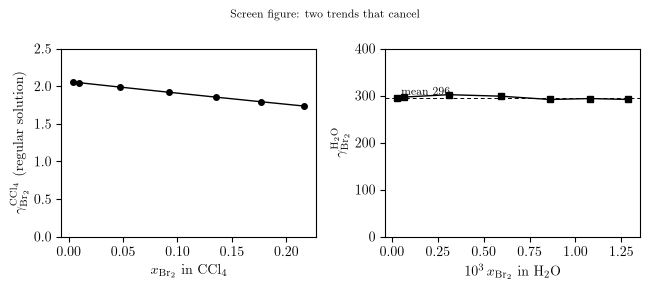

  gamma_org falls 16 % across the table
  the measured ratio rises 17 %
  their product moves 4 %


In [6]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.6, 2.9))

ax1.plot(x_ccl4, gamma_org, "o-", color="k", ms=4, lw=1.0)
ax1.set_xlabel(r"$x_{\rm Br_2}$ in CCl$_4$")
ax1.set_ylabel(r"$\gamma_{\rm Br_2}^{\rm CCl_4}$ (regular solution)")
ax1.set_ylim(0, 2.5)

ax2.plot(x_h2o * 1e3, gamma_aq, "s-", color="k", ms=4, lw=1.0)
ax2.axhline(gamma_aq.mean(), color="k", lw=0.7, ls=(0, (4, 3)))
ax2.text(0.05, gamma_aq.mean() + 6, f"mean {gamma_aq.mean():.0f}", fontsize=8)
ax2.set_xlabel(r"$10^3\,x_{\rm Br_2}$ in H$_2$O")
ax2.set_ylabel(r"$\gamma_{\rm Br_2}^{\rm H_2O}$")
ax2.set_ylim(0, 400)

fig.suptitle("Screen figure: two trends that cancel", fontsize=8)
fig.tight_layout()
plt.show()

print(f"  gamma_org falls {100*(1 - gamma_org[-1]/gamma_org[0]):.0f} % across the table")
print(f"  the measured ratio rises {100*(Kx[-1]/Kx[0] - 1):.0f} %")
print(f"  their product moves {100*(gamma_aq.max()/gamma_aq.min() - 1):.0f} %")

## What this measurement is good for

Bromine in water is a hard system to characterize directly. It is sparingly soluble, so
a vapor-liquid measurement gives a small pressure difference against a large background,
and the species is corrosive and volatile. What Illustration 11.4-1 does instead is put
the bromine where it is comfortable -- in carbon tetrachloride, where a model with no
adjustable parameters works -- measure only a ratio of concentrations, and get the hard
activity coefficient by division.

The same trick, in the same section, becomes the octanol-water partition coefficient of
environmental engineering: an activity coefficient in water of order $10^8$ measured as
a concentration ratio. Section 11.4's two halves are one idea.

**And the assumption that makes it work is stated, not derived.** The illustration
assumes the two solvents are mutually insoluble and that there is no volume change on
mixing. Water and carbon tetrachloride are a good case for the first (Illustration
11.2-3 puts the mutual solubilities near $10^{-3}$ mole fraction), and the second is
what makes the concentration-to-mole-fraction conversion a closed form at all. Neither
survives for a solute added in quantity, which is why Sec. 11.2 rather than Sec. 11.4
handles that case.

## Your turn

1. Drop the no-volume-change assumption and suppose the bromine-CCl$_4$ mixture
   contracts by 2 % on mixing at the most concentrated point. How much does
   $x_{\rm Br_2}$ move, and how much does the activity coefficient ratio?
2. Problem 11.4-4 gives the same kind of data for bromine between carbon disulfide and
   *aqueous potassium bromide* at three salt concentrations. Work it with the machinery
   here (carbon disulfide is in Table 9.6-1) and see whether $\gamma_{\rm Br_2}$ in the
   aqueous phase rises or falls with added salt. Which is salting in and which is
   salting out?
3. The regular solution model can only give $\gamma \ge 1$. What would it take for
   bromine in carbon tetrachloride to have $\gamma < 1$, and does anything in the data
   here rule that out?
4. Turn the calculation around: take $\gamma_{\rm Br_2}^{\rm H_2O} = 296$ as given and
   predict the aqueous solubility of bromine with Eq. 11.2-18. Compare with a handbook
   value, and account for the difference.
5. Problem 11.4-2 is partition chromatography -- gallic acid and *p*-hydroxybenzoic acid
   between ether and water, with $K_c$ of 0.25 and 8.0. Work parts (a), (b) and (c) with
   `partition.solute_split` and explain why five one-liter extractions beat one
   five-liter extraction.